In [ ]:
!pip install -q nltk scikit-learn pandas numpy scipy

In [ ]:
import pandas as pd
import numpy as np
import re
from scipy.sparse import hstack, csr_matrix

import nltk
nltk.download("vader_lexicon")
nltk.download("stopwords")

from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
CSV_PATH = "/content/drive/MyDrive/dataset/twcs.csv"

DEBUG_MODE = True
MAX_AMAZON_CONVERSATIONS = 50000
RANDOM_STATE = 42

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words("english"))

In [ ]:
def to_int_safe(x):
    try:
        if pd.isna(x):
            return None
        return int(float(x))
    except:
        return None

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in stop_words]
    return " ".join(tokens)

def sentiment_label(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive", score
    elif score <= -0.05:
        return "negative", score
    else:
        return "neutral", score

sent_order = {"negative": -1, "neutral": 0, "positive": 1}

def cpc_label(first_sent, last_sent):
    diff = sent_order[last_sent] - sent_order[first_sent]
    if diff > 0:
        return "Improved"
    elif diff < 0:
        return "Deteriorated"
    else:
        return "No Change"

In [ ]:
parent_map = {}
amazon_tweet_ids = set()

for chunk in pd.read_csv(
    CSV_PATH,
    usecols=["tweet_id", "author_id", "in_response_to_tweet_id"],
    chunksize=300000
):
    chunk["tweet_id"] = pd.to_numeric(chunk["tweet_id"], errors="coerce")
    chunk["in_response_to_tweet_id"] = pd.to_numeric(chunk["in_response_to_tweet_id"], errors="coerce")

    for row in chunk.itertuples(index=False):
        tid = to_int_safe(row.tweet_id)
        pid = to_int_safe(row.in_response_to_tweet_id)
        author = str(row.author_id).strip().lower()

        if tid is None:
            continue

        parent_map[tid] = pid

        if author == "amazonhelp":
            amazon_tweet_ids.add(tid)

print("Total tweets by amazonhelp:", len(amazon_tweet_ids))
print("Parent map size:", len(parent_map))

Total tweets by amazonhelp: 169840
Parent map size: 2811774


In [ ]:
root_cache = {}

def find_root(tweet_id):
    if tweet_id in root_cache:
        return root_cache[tweet_id]

    path = []
    cur = tweet_id

    while True:
        if cur in root_cache:
            root = root_cache[cur]
            break

        parent = parent_map.get(cur, None)

        if parent is None:
            root = cur
            break

        path.append(cur)
        cur = parent

    for p in path:
        root_cache[p] = root
    root_cache[tweet_id] = root
    return root

amazon_roots = set(find_root(tid) for tid in amazon_tweet_ids)

print("AmazonHelp conversation roots found:", len(amazon_roots))

AmazonHelp conversation roots found: 82534


In [ ]:
selected_chunks = []

for chunk in pd.read_csv(
    CSV_PATH,
    usecols=["tweet_id", "author_id", "inbound", "created_at", "text", "in_response_to_tweet_id"],
    chunksize=300000
):
    chunk["tweet_id"] = pd.to_numeric(chunk["tweet_id"], errors="coerce").astype("Int64")
    chunk["root_id"] = [find_root(int(t)) if pd.notna(t) else None for t in chunk["tweet_id"]]

    chunk = chunk[chunk["root_id"].isin(amazon_roots)]
    selected_chunks.append(chunk)

amazon_df = pd.concat(selected_chunks, ignore_index=True)
amazon_df["created_at"] = pd.to_datetime(amazon_df["created_at"], errors="coerce", utc=True)

print("Amazon-related tweets extracted:", len(amazon_df))
amazon_df.head()

/tmp/ipykernel_15043/136665852.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  amazon_df["created_at"] = pd.to_datetime(amazon_df["created_at"], errors="coerce", utc=True)


Amazon-related tweets extracted: 374042


,tweet_id,author_id,inbound,created_at,text,in_response_to_tweet_id,root_id
0,269,AmazonHelp,False,2017-11-22 09:23:01+00:00,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは...,272.0,272
1,270,115770,True,2017-11-22 09:24:30+00:00,@AmazonHelp ありがとうございます。\n今、電話で主人が対応していただいてます。,269.0,272
2,271,115770,True,2017-11-22 09:30:36+00:00,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎ...,269.0,272
3,273,AmazonHelp,False,2017-11-22 09:40:27+00:00,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました...,271.0,272
4,274,115770,True,2017-11-22 09:44:04+00:00,@AmazonHelp こちらこそありがとうございました。,273.0,272


In [ ]:
conversation_rows = []

amazon_df = amazon_df.sort_values(["root_id", "created_at"])

for root_id, group in amazon_df.groupby("root_id"):
    group = group.sort_values("created_at")

    customer_msgs = group[group["inbound"] == True].copy()
    customer_msgs = customer_msgs.dropna(subset=["text"])

    if len(customer_msgs) < 2:
        continue

    first_row = customer_msgs.iloc[0]
    last_row = customer_msgs.iloc[-1]

    first_text_raw = str(first_row["text"])
    last_text_raw = str(last_row["text"])

    first_text = clean_text(first_text_raw)
    last_text = clean_text(last_text_raw)

    if len(first_text.strip()) == 0 or len(last_text.strip()) == 0:
        continue

    first_sent, first_score = sentiment_label(first_text)
    last_sent, last_score = sentiment_label(last_text)

    label = cpc_label(first_sent, last_sent)

    num_tweets = len(group)
    num_customer_tweets = len(customer_msgs)
    num_agent_tweets = len(group[group["inbound"] == False])

    if group["created_at"].notna().all():
        duration_minutes = (group["created_at"].max() - group["created_at"].min()).total_seconds() / 60.0
    else:
        duration_minutes = 0.0

    avg_tweet_len = group["text"].fillna("").astype(str).str.len().mean()
    response_ratio = num_agent_tweets / max(num_customer_tweets, 1)

    conversation_rows.append({
        "root_id": root_id,
        "text_feature": first_text,
        "initial_sentiment": first_sent,
        "initial_sentiment_score": first_score,
        "num_tweets": num_tweets,
        "num_customer_tweets": num_customer_tweets,
        "num_agent_tweets": num_agent_tweets,
        "duration_minutes": duration_minutes,
        "avg_tweet_len": avg_tweet_len,
        "response_ratio": response_ratio,
        "final_sentiment": last_sent,
        "cpc_label": label
    })

features_df = pd.DataFrame(conversation_rows)

print("Total modeled conversations:", len(features_df))
print(features_df["cpc_label"].value_counts())
features_df.head()

Total modeled conversations: 43869
cpc_label
No Change       18489
Improved        15586
Deteriorated     9794
Name: count, dtype: int64


,root_id,text_feature,initial_sentiment,initial_sentiment_score,num_tweets,num_customer_tweets,num_agent_tweets,duration_minutes,avg_tweet_len,response_ratio,final_sentiment,cpc_label
0,617,way drop ball customer service pissed right,negative,-0.7430,5,3,2,75.900000,116.200000,0.666667,neutral,Improved
1,624,also beim addams family film prime sind bild u...,neutral,0.0000,4,2,2,21.916667,79.000000,1.000000,negative,Deteriorated
2,630,playerunknown battlegrounds available preorder...,negative,-0.1531,5,3,2,925.750000,113.400000,0.666667,negative,No Change
3,643,bought echo show recognize single account hous...,negative,-0.5859,7,4,3,1361.366667,81.285714,0.750000,positive,Improved
4,646,item delivered tracking says handed hour ago n...,neutral,0.0000,4,2,2,631.066667,127.250000,1.000000,negative,Deteriorated


In [ ]:
if DEBUG_MODE and len(features_df) > MAX_AMAZON_CONVERSATIONS:
    num_classes = features_df["cpc_label"].nunique()
    per_class = max(1, MAX_AMAZON_CONVERSATIONS // num_classes)

    features_df = (
        features_df.groupby("cpc_label", group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), per_class), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )

print("Final experiment dataset size:", len(features_df))
print(features_df["cpc_label"].value_counts())

Final experiment dataset size: 43869
cpc_label
No Change       18489
Improved        15586
Deteriorated     9794
Name: count, dtype: int64


In [ ]:
numeric_cols = [
    "initial_sentiment_score",
    "num_tweets",
    "num_customer_tweets",
    "num_agent_tweets",
    "duration_minutes",
    "avg_tweet_len",
    "response_ratio"
]

X = features_df[["text_feature"] + numeric_cols].copy()
y = features_df["cpc_label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (35095, 8)
Test shape: (8774, 8)


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_text = vectorizer.fit_transform(X_train["text_feature"])
X_test_text = vectorizer.transform(X_test["text_feature"])

selector = SelectKBest(chi2, k=min(3000, X_train_text.shape[1]))
X_train_text_sel = selector.fit_transform(X_train_text, y_train)
X_test_text_sel = selector.transform(X_test_text)

scaler = MinMaxScaler()
X_train_num = scaler.fit_transform(X_train[numeric_cols].astype(float))
X_test_num = scaler.transform(X_test[numeric_cols].astype(float))

X_train_final = hstack([X_train_text_sel, csr_matrix(X_train_num)])
X_test_final = hstack([X_test_text_sel, csr_matrix(X_test_num)])

print("Train matrix shape:", X_train_final.shape)
print("Test matrix shape:", X_test_final.shape)

Train matrix shape: (35095, 3007)
Test matrix shape: (8774, 3007)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "SVM": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Naive Bayes": MultinomialNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

In [ ]:
results = []

for name, model in models.items():
    print(f"Training: {name}")
    model.fit(X_train_final, y_train)
    preds = model.predict(X_test_final)

    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1, 4)
    })

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df

Training: Logistic Regression
Training: SVM
Training: Naive Bayes
Training: KNN
Training: Decision Tree
Training: Random Forest
Training: Bagging


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.6247,0.6078,0.5885,0.5834
1,Bagging,0.6120,0.5938,0.5848,0.5823
2,Logistic Regression,0.5699,0.5600,0.5889,0.5666
3,SVM,0.5711,0.5508,0.5677,0.5553
4,Decision Tree,0.5532,0.5420,0.5492,0.5450
5,KNN,0.5145,0.4880,0.4894,0.4853
6,Naive Bayes,0.5348,0.5220,0.4606,0.4232


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

best_model = models[best_model_name]
best_preds = best_model.predict(X_test_final)

print("\nClassification Report:\n")
print(classification_report(y_test, best_preds, digits=4))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, best_preds))

Best model: Random Forest

Classification Report:

              precision    recall  f1-score   support

Deteriorated     0.5574    0.3150    0.4025      1959
    Improved     0.6816    0.8617    0.7611      3117
   No Change     0.5845    0.5890    0.5867      3698

    accuracy                         0.6247      8774
   macro avg     0.6078    0.5885    0.5834      8774
weighted avg     0.6129    0.6247    0.6076      8774


Confusion Matrix:

[[ 617  203 1139]
 [  22 2686  409]
 [ 468 1052 2178]]


In [ ]:
results_df.to_csv("/content/drive/MyDrive/cpc_results_table.csv", index=False)
features_df.to_csv("/content/drive/MyDrive/cpc_conversation_dataset.csv", index=False)

print("Saved to Google Drive:")
print("/content/drive/MyDrive/cpc_results_table.csv")
print("/content/drive/MyDrive/cpc_conversation_dataset.csv")

Saved to Google Drive:
/content/drive/MyDrive/cpc_results_table.csv
/content/drive/MyDrive/cpc_conversation_dataset.csv


In [ ]:
print("CPC Label Distribution:")
print(features_df["cpc_label"].value_counts())
print()

print("CPC Label Percentage:")
print((features_df["cpc_label"].value_counts(normalize=True) * 100).round(2))

CPC Label Distribution:
cpc_label
No Change       18489
Improved        15586
Deteriorated     9794
Name: count, dtype: int64

CPC Label Percentage:
cpc_label
No Change       42.15
Improved        35.53
Deteriorated    22.33
Name: proportion, dtype: float64


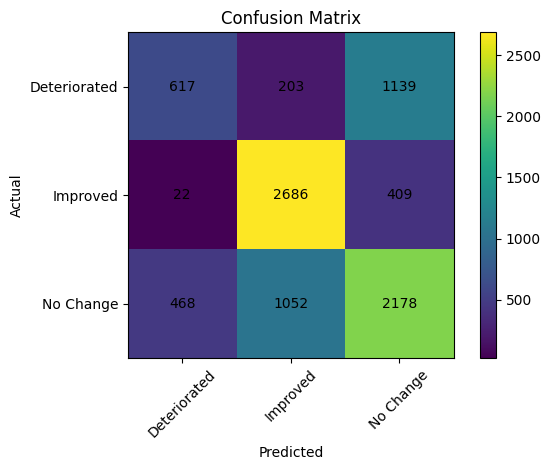

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, best_preds)
labels = ["Deteriorated", "Improved", "No Change"]

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=45)
plt.yticks(tick_marks, labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()

plt.savefig("/content/cpc_cm.png")
plt.show()

In [ ]:
from google.colab import files
files.download("/content/cpc_cm.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

sample_df = X_test.copy()
sample_df["Actual"] = y_test.values
sample_df["Predicted"] = best_preds

# take 5 random examples
sample_df = sample_df.sample(5, random_state=42)

sample_df[["text_feature", "Actual", "Predicted"]]

,text_feature,Actual,Predicted
43645,amazon prime order information often unreliabl...,Deteriorated,Deteriorated
34397,impressed customer service mins phone sort,No Change,Deteriorated
38063,someone used bank card amazon without permissi...,Improved,Improved
37972,spend amp get day free shipping also sorry los...,Deteriorated,No Change
26490,echo alarm going minutes alexa listen driving ...,Improved,Improved


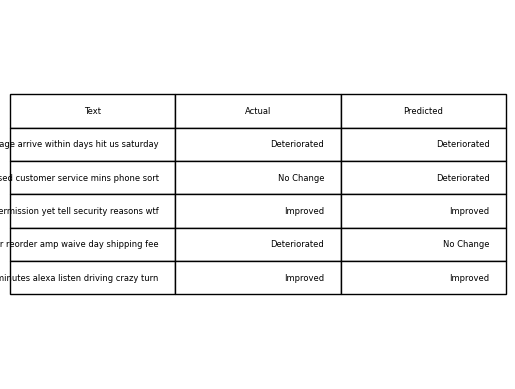

In [ ]:
fig, ax = plt.subplots()
ax.axis('off')

table = ax.table(
    cellText=sample_df[["text_feature", "Actual", "Predicted"]].values,
    colLabels=["Text", "Actual", "Predicted"],
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(6)
table.scale(1, 2)

plt.savefig("/content/cpc_examples.png", bbox_inches='tight')
plt.show()

In [ ]:
files.download("/content/cpc_examples.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>